In [16]:
import kagglehub

path = kagglehub.dataset_download("sijovm/used-cars-data-from-ebay-kleinanzeigen")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\Usuario\.cache\kagglehub\datasets\sijovm\used-cars-data-from-ebay-kleinanzeigen\versions\1


In [17]:
# Importando as bibliotecas
import numpy as np
import pandas as pd
import seaborn as sb
import matplotlib as mat
import matplotlib.pyplot as plt

In [18]:
# Criando o dataframe
import os
cars = pd.read_csv(os.path.join(path, 'autos.csv'), encoding='latin-1')
print(cars.shape)

(371528, 20)


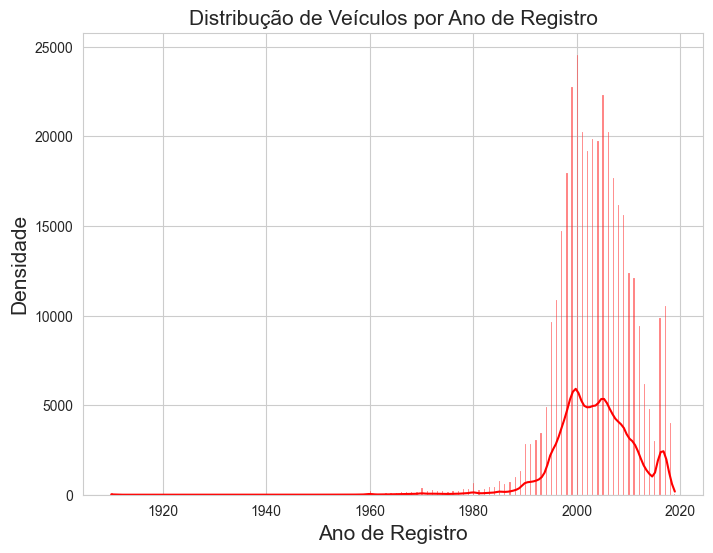

In [28]:
# Atividade 1 - Criando um Histograma para mostrar a Distribuição de Veículos com base no Ano de Registro
cars_filtered = cars[(cars['yearOfRegistration'] < 2020) & (cars['yearOfRegistration'] > 1900)]

fig, ax = plt.subplots(figsize=(8, 6))
sb.histplot(cars_filtered['yearOfRegistration'], color='red', kde=True, ax=ax)
ax.set_title('Distribução de Veículos por Ano de Registro', fontsize=15)
ax.set_ylabel("Densidade", fontsize=15)
ax.set_xlabel("Ano de Registro", fontsize=15)
plt.show()

C:\Users\Usuario\AppData\Local\Temp\ipykernel_3808\294222824.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.boxplot(x="vehicleType", y="price", data=cars_price_filtered, palette='Set2')


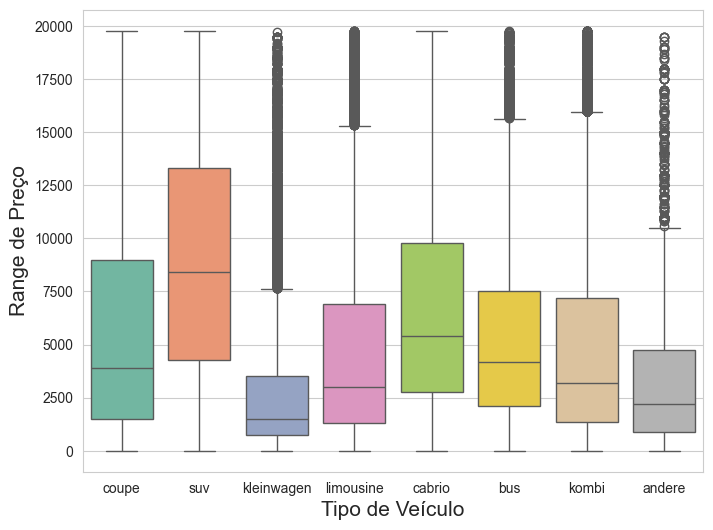

In [20]:
# Atividade 2 - Criando um Boxplot para avaliar os outliers
cars_price_filtered = cars[cars['price'] < cars['price'].quantile(0.95)]

sb.set_style("whitegrid")
fig, ax = plt.subplots(figsize=(8, 6))
sb.boxplot(x="vehicleType", y="price", data=cars_price_filtered, palette='Set2')
ax.xaxis.set_label_text("Tipo de Veículo", fontsize=15)
ax.yaxis.set_label_text("Range de Preço", fontsize=15)
plt.show()

C:\Users\Usuario\AppData\Local\Temp\ipykernel_3808\3632830949.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  graf = sb.catplot(x="vehicleType", data=cars, kind="count", palette="BuPu", height=6, aspect=1.5)


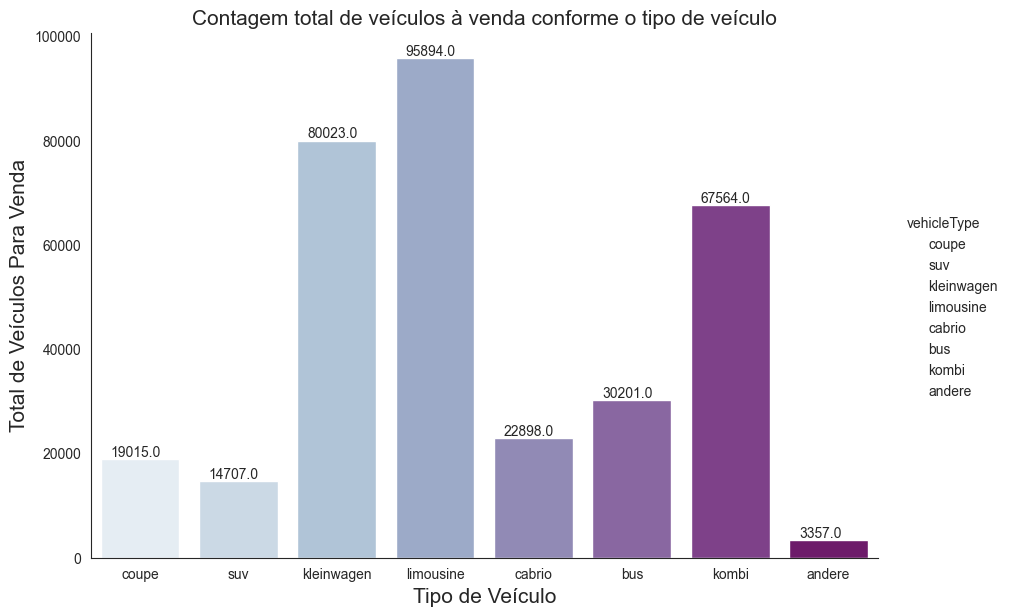

In [21]:
# Atividade 3 - Crie um Count Plot que mostre o número de veículos pertencentes a cada categoria
sb.set_style("white")
graf = sb.catplot(x="vehicleType", data=cars, kind="count", palette="BuPu", height=6, aspect=1.5)
graf.ax.xaxis.set_label_text("Tipo de Veículo", fontsize=15)
graf.ax.yaxis.set_label_text("Total de Veículos Para Venda", fontsize=15)
graf.ax.set_title("Contagem total de veículos à venda conforme o tipo de veículo", fontsize=15)

# Para mostrar as contagens na parte superior da barra
for p in graf.ax.patches:
    graf.ax.annotate((p.get_height()), (p.get_x()+0.1, p.get_height()+500))

C:\Users\Usuario\AppData\Local\Temp\ipykernel_3808\2905238324.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  graf = sb.catplot(y="brand", data=cars, kind="count", height=7, aspect=1.5, palette='husl')


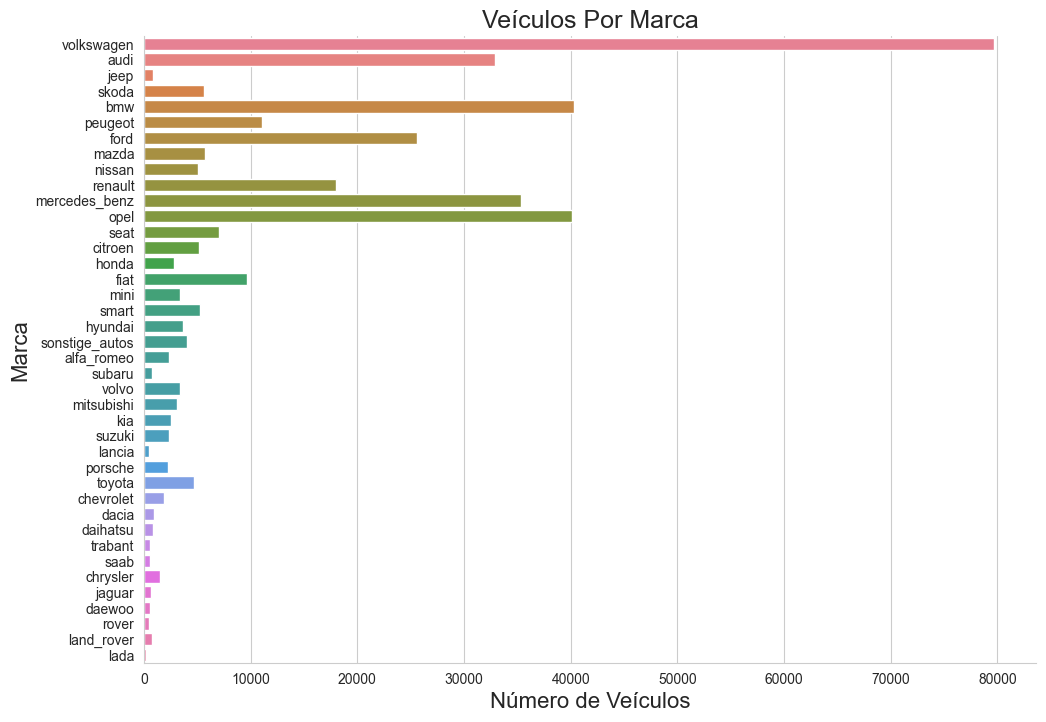

In [22]:
# Atividade 4 - Criando um Plot que mostre o número de veículos pertencentes a cada marca
sb.set_style("whitegrid")
graf = sb.catplot(y="brand", data=cars, kind="count", height=7, aspect=1.5, palette='husl')
graf.ax.set_title("Veículos Por Marca", fontdict={'size':18})
graf.ax.xaxis.set_label_text("Número de Veículos", fontdict={'size':16})
graf.ax.yaxis.set_label_text("Marca", fontdict={'size':16})
plt.show()

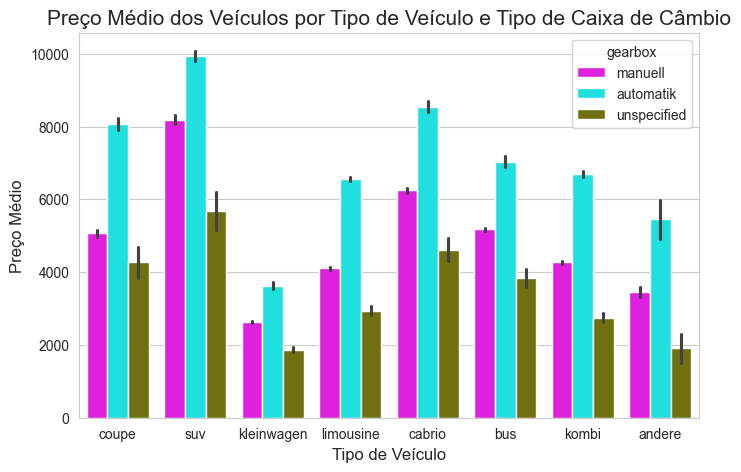

In [23]:
# Atividade 5 - Criando um Plot com o Preço Médio dos Veículos por Tipo de Veículo e Tipo de Caixa de Câmbio
from seaborn import barplot

cars_filtered_price = cars[cars['price'] < cars['price'].quantile(0.95)]

cars_filtered_price['gearbox'] = cars_filtered_price['gearbox'].fillna('unspecified')

fig, ax = plt.subplots(figsize=(8, 5))
colors = ["magenta", "cyan", "olive"]
ax = barplot(x="vehicleType", y="price", hue="gearbox", data=cars_filtered_price, palette=colors, ax=ax)
ax.set_title("Preço Médio dos Veículos por Tipo de Veículo e Tipo de Caixa de Câmbio", fontdict={'size':15})
ax.xaxis.set_label_text("Tipo de Veículo", fontdict={'size':12})
ax.yaxis.set_label_text("Preço Médio", fontdict={'size':12})
plt.show()

C:\Users\Usuario\AppData\Local\Temp\ipykernel_3808\3026187763.py:10: UserWarning: The palette list has more values (4) than needed (2), which may not be intended.
  ax = barplot(x="gearbox", y="price", hue="seller", palette=colors, data=cars_filtered_price_act6, ax=ax)


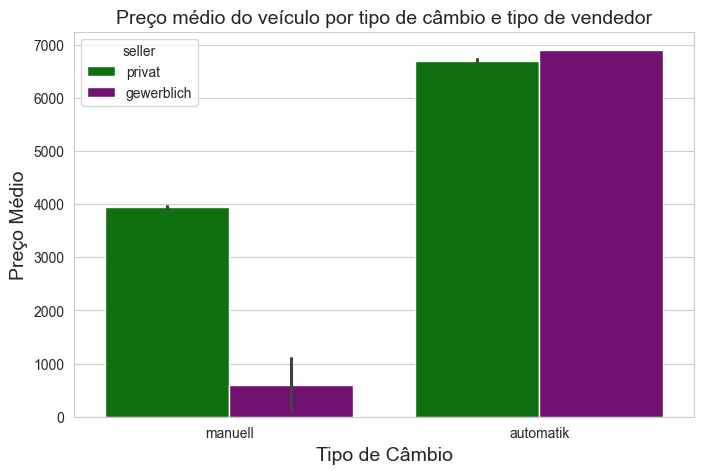

In [24]:
# Atividade 6 - Criando um Barplot com o Preço médio do veículo por tipo de vendedor e tipo de câmbio
from seaborn import barplot

cars_filtered_price_act6 = cars[cars['price'] < cars['price'].quantile(0.95)]

cars_filtered_price_act6['seller'] = cars_filtered_price_act6['seller'].fillna('unspecified')

fig, ax = plt.subplots(figsize=(8,5))
colors = ["green", "purple", "yellow", "red"]
ax = barplot(x="gearbox", y="price", hue="seller", palette=colors, data=cars_filtered_price_act6, ax=ax)
ax.set_title("Preço médio do veículo por tipo de câmbio e tipo de vendedor", fontsize=14)
ax.xaxis.set_label_text("Tipo de Câmbio", fontsize=14)
ax.yaxis.set_label_text("Preço Médio", fontsize=14)
plt.show()

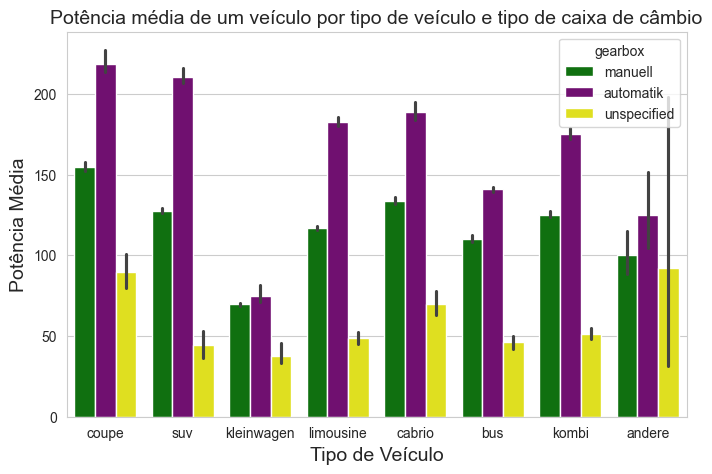

In [25]:
# Atividade 7 - Criando um Barplot com a Potência média por tipo de veículo e caixa de câmbio
from seaborn import barplot as sns_barplot

cars['gearbox'] = cars['gearbox'].fillna('unspecified')

colors = ["green", "purple", "yellow"]
fig, ax = plt.subplots(figsize=(8, 5))
ax = sns_barplot(x="vehicleType", y="powerPS", hue="gearbox", palette=colors, data=cars, ax=ax)
ax.set_title("Potência média de um veículo por tipo de veículo e tipo de caixa de câmbio", fontsize=14)
ax.xaxis.set_label_text("Tipo de Veículo", fontsize=14)
ax.yaxis.set_label_text("Potência Média", fontsize=14)
plt.show()

In [26]:
# Atividade 8 - Calculando a média de preço por marca e por veículo
data_list = [] # criando uma lista para armazenar os dicionários

for b in list(cars["brand"].unique()):
    for v in list(cars["vehicleType"].unique()):
        z = cars[(cars["brand"] == b) & (cars["vehicleType"] == v)]["price"].mean()
        
        data_list.append({'brand': b, 'vehicleType': v, 'avgPrice': z})

mv = pd.DataFrame(data_list)

mv["avgPrice"] = mv["avgPrice"].fillna(0) 
mv["avgPrice"] = mv["avgPrice"].astype(int)

mv.head()
mv.head(-10)

,brand,vehicleType,avgPrice
0,volkswagen,NaN,0
1,volkswagen,coupe,14854
2,volkswagen,suv,15898
3,volkswagen,kleinwagen,9261
4,volkswagen,limousine,10849
...,...,...,...
345,land_rover,kleinwagen,0
346,land_rover,limousine,875
347,land_rover,cabrio,2675
348,land_rover,bus,0


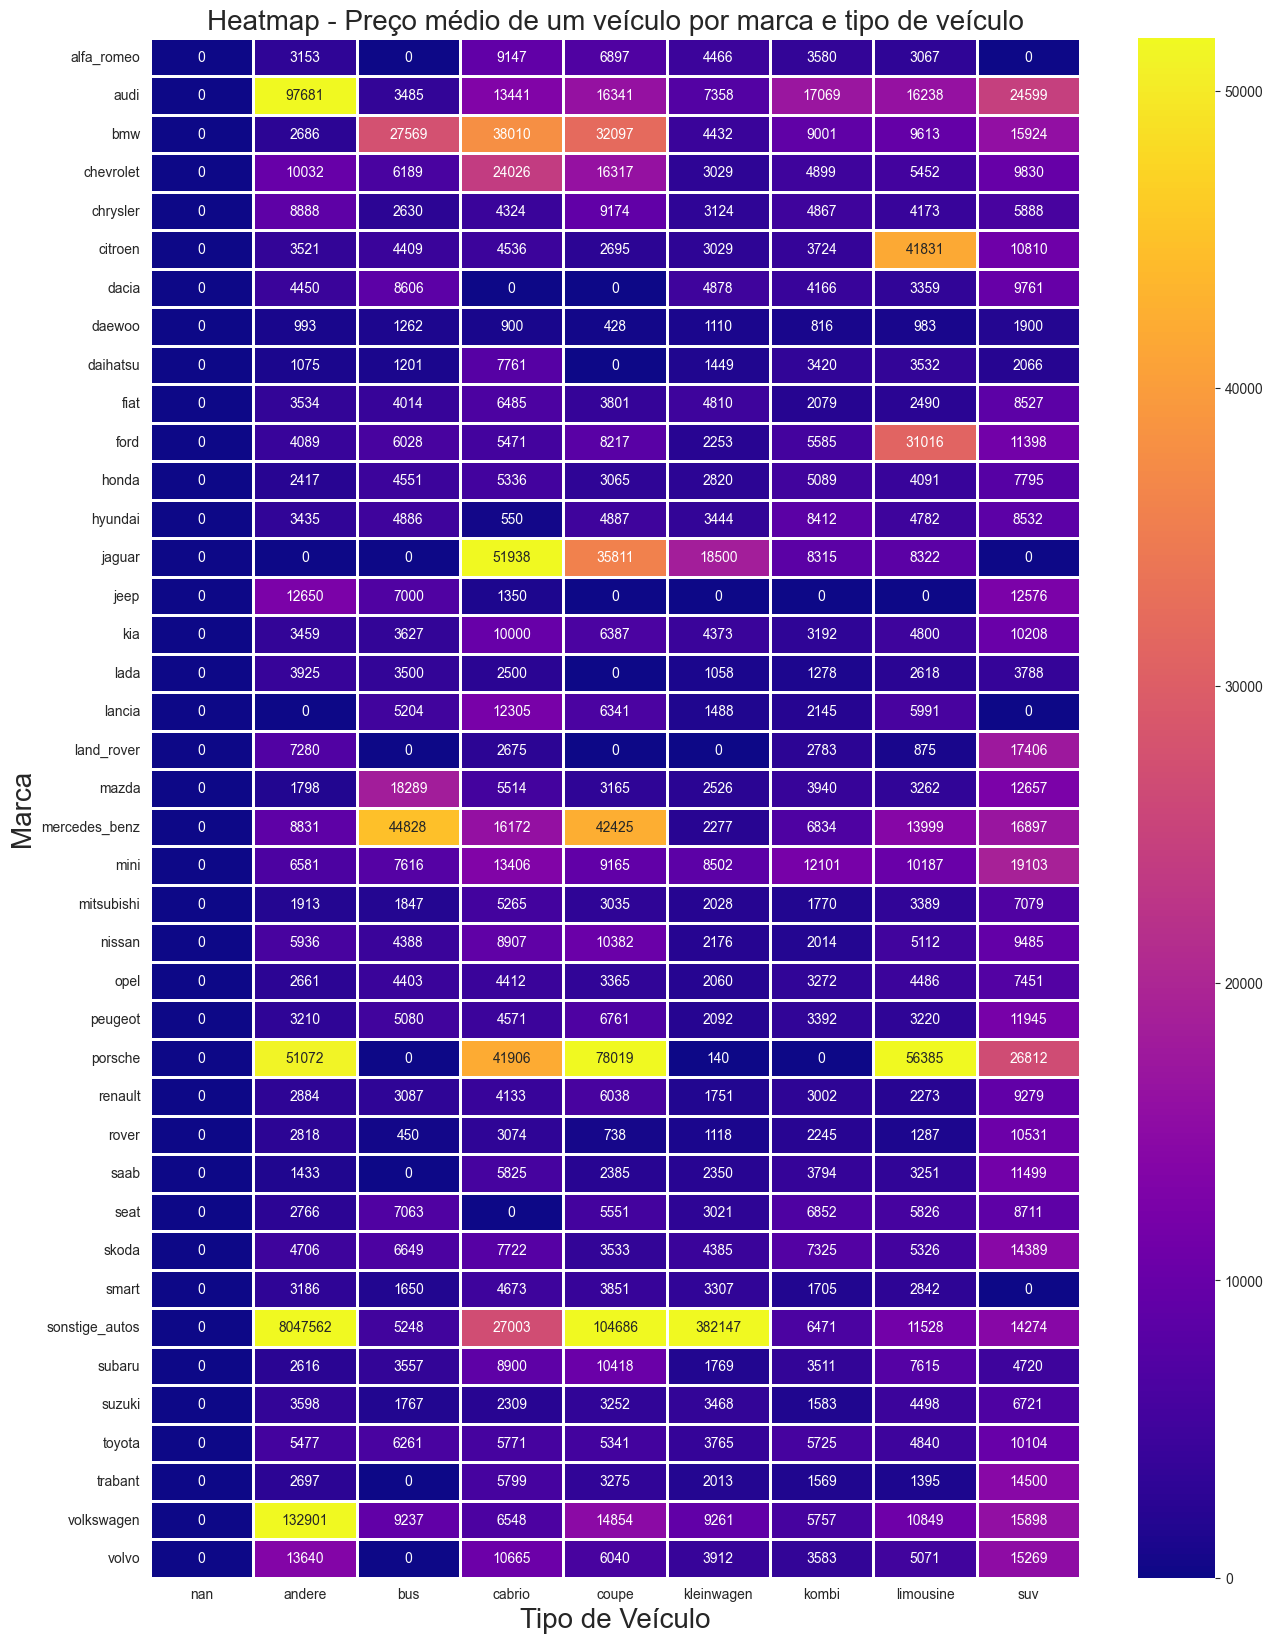

In [27]:
# Atividade 9 - Criando um Heatmap com Preço médio de um veículo por marca e tipo de veículo

import seaborn as sns
import matplotlib.pyplot as plt

tri = mv.pivot(index="brand", columns="vehicleType", values="avgPrice")
tri.fillna(0, inplace=True)

fig, ax = plt.subplots(figsize=(15, 20))

sns.heatmap(tri, linewidths=1, cmap="plasma", annot=True, ax=ax, fmt=".0f", robust=True)

ax.set_title("Heatmap - Preço médio de um veículo por marca e tipo de veículo", fontsize=20)
ax.xaxis.set_label_text("Tipo de Veículo", fontsize=20)
ax.yaxis.set_label_text("Marca", fontsize=20)

plt.show()